# Proyek Analisis Data: E-commerce-public-dataset
- **Nama:** Nadya Dinda Aisha Putri
- **Email:** cdcc006d6x0409@student.devacademy.id
- **ID Dicoding:** CDCC006D6X0409

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa saja yang menghasilkan total pendapatan tertinggi, dan bagaimana distribusi kontribusinya?
- **Pertanyaan 2:** Bagaimana hubungan delivery time terhadap review score?

## Import Semua Packages/Library yang Digunakan

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

In [37]:
# Load Dataset
data_path = "E-commerce-public-dataset"

data = {}

for file in os.listdir(data_path):
    if file.endswith(".csv"):
        file_path = os.path.join(data_path, file)
        df_name = file.replace(".csv", "")
        
        data[df_name] = pd.read_csv(file_path)
        print(f"✅ Loaded: {df_name} ({data[df_name].shape[0]} rows, {data[df_name].shape[1]} cols)")

customers = data['customers_dataset']
orders = data['orders_dataset']
products = data['products_dataset']

✅ Loaded: customers_dataset (99441 rows, 5 cols)
✅ Loaded: geolocation_dataset (1000163 rows, 5 cols)
✅ Loaded: orders_dataset (99441 rows, 8 cols)
✅ Loaded: order_items_dataset (112650 rows, 7 cols)
✅ Loaded: order_payments_dataset (103886 rows, 5 cols)
✅ Loaded: order_reviews_dataset (99224 rows, 7 cols)
✅ Loaded: products_dataset (32951 rows, 9 cols)
✅ Loaded: product_category_name_translation (71 rows, 2 cols)
✅ Loaded: sellers_dataset (3095 rows, 4 cols)


In [38]:
for name, df in data.items():
    print(f"\n📦 {name}")
    print(df.info())


📦 customers_dataset
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB
None

📦 geolocation_dataset
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1

#### Load df ...

**Insight:** (Opsional)
- xxx
- xxx

### Assessing Data

In [39]:
# Missing Values
for name, df in data.items():
    print(f"\n🔍 Missing values in {name}:")
    print(df.isnull().sum())


🔍 Missing values in customers_dataset:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

🔍 Missing values in geolocation_dataset:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

🔍 Missing values in orders_dataset:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

🔍 Missing values in order_items_dataset:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype:

In [40]:
# Duplicate Rows
for name, df in data.items():
    print(f"\n🔁 Duplicate rows in {name}:")
    dup_count = df.duplicated().sum()
    print(f"Total duplicate rows: {dup_count}")


🔁 Duplicate rows in customers_dataset:
Total duplicate rows: 0

🔁 Duplicate rows in geolocation_dataset:
Total duplicate rows: 261831

🔁 Duplicate rows in orders_dataset:
Total duplicate rows: 0

🔁 Duplicate rows in order_items_dataset:
Total duplicate rows: 0

🔁 Duplicate rows in order_payments_dataset:
Total duplicate rows: 0

🔁 Duplicate rows in order_reviews_dataset:
Total duplicate rows: 0

🔁 Duplicate rows in products_dataset:
Total duplicate rows: 0

🔁 Duplicate rows in product_category_name_translation:
Total duplicate rows: 0

🔁 Duplicate rows in sellers_dataset:
Total duplicate rows: 0


In [41]:
# Cek invalid values
for name, df in data.items():
    print(f"\n⚠️ Invalid values in {name}:")
    
    for col in df.columns:
        
        # cek string kosong
        if df[col].dtype == 'object':
            empty_count = (df[col].astype(str).str.strip() == "").sum()
            if empty_count > 0:
                print(f"{col}: {empty_count} empty values")
        
        # cek nilai negatif (khusus numerik)
        if df[col].dtype in ['int64', 'float64']:
            negative_count = (df[col] < 0).sum()
            if negative_count > 0:
                print(f"{col}: {negative_count} negative values")


⚠️ Invalid values in customers_dataset:

⚠️ Invalid values in geolocation_dataset:
geolocation_lat: 998827 negative values
geolocation_lng: 1000160 negative values

⚠️ Invalid values in orders_dataset:

⚠️ Invalid values in order_items_dataset:

⚠️ Invalid values in order_payments_dataset:

⚠️ Invalid values in order_reviews_dataset:

⚠️ Invalid values in products_dataset:

⚠️ Invalid values in product_category_name_translation:

⚠️ Invalid values in sellers_dataset:


In [42]:
# Outlier Detection (IQR Method)
for name, df in data.items():
    print(f"\n📊 Outliers in {name}:")
    
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        if len(outliers) <= 0:
            print(f"{col}: {len(outliers)} outliers")


📊 Outliers in customers_dataset:
customer_zip_code_prefix: 0 outliers

📊 Outliers in geolocation_dataset:
geolocation_zip_code_prefix: 0 outliers

📊 Outliers in orders_dataset:

📊 Outliers in order_items_dataset:

📊 Outliers in order_payments_dataset:

📊 Outliers in order_reviews_dataset:

📊 Outliers in products_dataset:

📊 Outliers in product_category_name_translation:

📊 Outliers in sellers_dataset:
seller_zip_code_prefix: 0 outliers


#### Identifying ... problem

**Steps to Take:**
- xxx
- xxx

**Insight:** (Opsional)
- xxx
- xxx

### Cleaning Data

In [43]:
customers = data['customers_dataset']
orders = data['orders_dataset']
order_items = data['order_items_dataset']
products = data['products_dataset']
order_reviews = data['order_reviews_dataset']
payments = data['order_payments_dataset']

In [20]:
# Products → category kosong jadi 'unknown'
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# Orders → buang yang tidak punya tanggal penting
orders = orders.dropna(subset=['order_purchase_timestamp'])

In [21]:
# Remove duplicate rows
order_reviews = order_reviews.drop_duplicates(subset=['review_id'])
order_items = order_items.drop_duplicates()
orders = orders.drop_duplicates()

In [22]:
# Melakukan convert datetime terlebih dulu
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# Melakukan filter yang hanya delivered
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered = orders_delivered.dropna(subset=['order_delivered_customer_date'])

In [23]:
# Feature Engineering (Delivery Time)
orders_delivered['delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_purchase_timestamp']
).dt.days

In [24]:
# Harga & ongkir tidak boleh negatif
order_items = order_items[(order_items['price'] >= 0) & 
                          (order_items['freight_value'] >= 0)]

In [25]:
print("✅ CLEANING SUMMARY")
print(f"Orders (delivered only): {len(orders_delivered):,}")
print(f"Products (clean): {len(products):,}")
print(f"Order reviews (deduplicated): {len(order_reviews):,}")
print(f"Order items (clean): {len(order_items):,}")

✅ CLEANING SUMMARY
Orders (delivered only): 96,470
Products (clean): 32,951
Order reviews (deduplicated): 98,410
Order items (clean): 112,650


In [47]:
# Merge jadi 1 tabel
main_df = orders_delivered.merge(order_items, on='order_id') \
                          .merge(products, on='product_id') \
                          .merge(payments, on='order_id') \
                          .merge(customers, on='customer_id')
# Menambahkan revenue
main_df['revenue'] = main_df['price'] + main_df['freight_value']

#### Fixing ... problem

**Insight:** (Opsional)
- xxx
- xxx

## Exploratory Data Analysis (EDA)

### Explore ...

In [44]:
# Pertanyaan 1 
# Kategori produk apa saja yang menghasilkan total pendapatan tertinggi, dan bagaimana distribusi kontribusinya?
# total revenue per kategori
category_revenue = main_df.groupby('product_category_name')['revenue'] \
                          .sum() \
                          .sort_values(ascending=False)

# hitung kontribusi (%)
total_revenue = category_revenue.sum()

category_contribution = (category_revenue / total_revenue) * 100

# gabungkan
category_summary = pd.DataFrame({
    'total_revenue': category_revenue,
    'contribution_%': category_contribution
})

category_summary.head(10)

,total_revenue,contribution_%
product_category_name,,
beleza_saude,1465431.40,8.958588
cama_mesa_banho,1367218.41,8.358184
relogios_presentes,1318544.52,8.060627
esporte_lazer,1179946.30,7.213338
informatica_acessorios,1093194.67,6.683002
moveis_decoracao,939848.41,5.745553
utilidades_domesticas,813079.68,4.970581
cool_stuff,724635.24,4.429896
automotivo,699581.58,4.276736


In [48]:
# Pertanyaan 2
# Bagaimana hubungan delivery time terhadap review score?
# gabungkan review
main_df = main_df.merge(
    order_reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

# rata-rata delivery per score
delivery_vs_review = main_df.groupby('review_score')['delivery_days'].mean()

delivery_vs_review

review_score
1.0    19.091582
2.0    15.381893
3.0    13.550731
4.0    11.778330
5.0    10.203350
Name: delivery_days, dtype: float64

**Insight:**
- [Q1]
  * Kategori Health & Beauty = beleza_saude,
  * Watches & Gifts = relogios_presentesc
  * cama_mesa_banho = Bed Bath & Table
  Dengan distribusi yang menunjukkan konsentrasi pada beberapa kategori dominan.
- [Q2] Terdapat korelasi negatif antara delivery time dan review score, di mana semakin lama waktu pengiriman, semakin rendah kepuasan pelanggan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

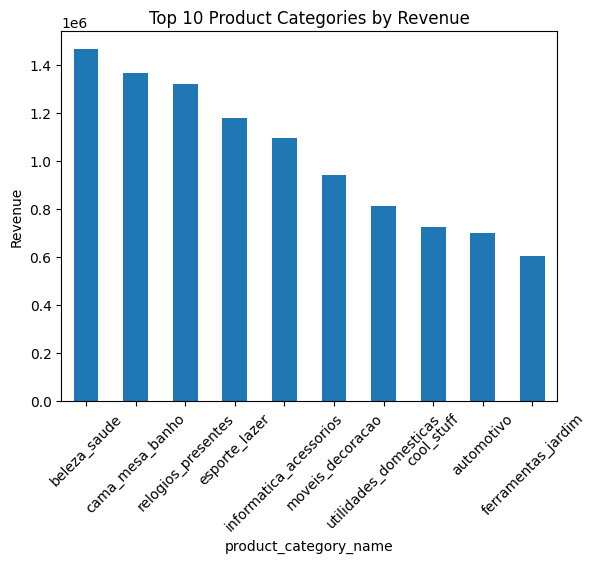

In [50]:
category_revenue.head(10).plot(kind='bar')
plt.title('Top 10 Product Categories by Revenue')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2:

💡 Insight Utama
1. 📌 Revenue Terkonsentrasi di Kategori Tertentu
* Perbedaan antara rank 1 dan 10 cukup signifikan
* Top kategori jelas mendominasi
2. . 🛍️ Dominasi Produk Lifestyle & Household
Kategori atas didominasi:
* kecantikan
* hadiah
* kebutuhan rumah
3. 📉 Pola Long-Tail
* Setelah top 5 → kontribusi makin kecil
* Banyak kategori kecil di belakang

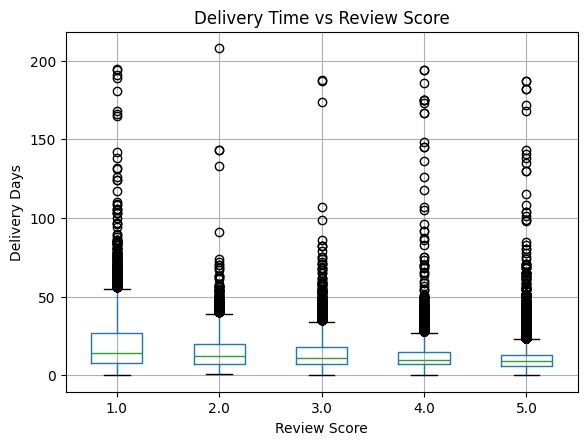

In [49]:
main_df.boxplot(column='delivery_days', by='review_score')
plt.title('Delivery Time vs Review Score')
plt.suptitle('')
plt.xlabel('Review Score')
plt.ylabel('Delivery Days')
plt.show()

In [ ]:
1. Median Turun Seiring Naiknya Rating
* Rating 1 → delivery lebih lama
* Rating 5 → delivery lebih cepat
2. Spread (Sebaran) Lebih Besar di Rating Rendah
* Rating 1–2 → variasi delivery besar (tidak konsisten)
* Rating 4–5 → lebih stabil
3. Banyak Outlier (Titik di Atas)
* Ada delivery sampai:
* 100–200 hari 

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Selama 2017–2018, revenue Olist didominasi oleh kategori seperti Health & Beauty, Watches & Gifts, dan Bed, Bath & Table, dengan distribusi yang menunjukkan pola konsentrasi pada beberapa kategori utama (long-tail distribution).
- **Conclusion pertanyaan 2:** Terdapat hubungan negatif yang kuat antara waktu pengiriman dan review score. Order dengan delivery time lebih cepat cenderung mendapatkan rating lebih tinggi, sementara keterlambatan dan ketidakkonsistenan pengiriman berkontribusi terhadap penurunan kepuasan pelanggan.

**Rekomendasi Action Item:**
[Q1]
- Prioritaskan fulfillment & pengiriman cepat untuk 3 kategori teratas
- Terapkan SLA khusus (misal: ≤ 10 hari) untuk kategori ini
- Pilih courier dengan performa terbaik khusus top categories
- Monitor harian: avg delivery_days & on-time rate
 [Q2]
- Buat alert keterlambatan (misal > 15 hari)
- Kirim notifikasi proaktif ke customer kalau delay
- Beri kompensasi ringan (voucher) untuk delay ekstrem
- Investigasi order dengan delivery > 30 hari (root cause)